In [8]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from geopy.geocoders import Nominatim
import pydeck as pdk
from statsmodels.tsa.arima.model import ARIMA

### Import and Export

In [9]:
import_data = pd.read_csv('TradeMerchTotal_Import.csv',
                          usecols=[0,*range(53,79)],
                          index_col=0,
                          names=['Region',*map(str,range(2000,2026))],
                          skiprows=1,
                          nrows=11)

In [10]:
import_data

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
World,6652863,6410067,6662108,7778802,9476842,10797252,12379818,14259986,16517743,12752740,...,16203550,17967174,19808697,19323221,17874104,22572793,25674035,24298956,24833028,26607603
Africa,128137,132567,134283,164244,210103,254783,301820,377482,481589,416853,...,508022,524505,591073,589748,491447,616240,739815,717898,721116,788936
Americas,1894047,1787563,1784633,1917967,2256353,2594864,2918993,3173486,3520423,2633264,...,3602154,3879006,4218608,4123340,3747764,4712633,5502741,5197784,5432693,5678795
Asia,1827704,1713764,1822648,2172435,2761272,3224708,3729090,4322635,5248853,4206727,...,5942386,6751236,7506822,7308427,6821769,8809718,9799540,9200546,9603486,10254218
Central Asia,10756,12665,12437,15181,21626,26398,34271,47958,60111,49841,...,48349,53142,60668,70950,67247,78848,97581,119064,118289,132245
Eastern Asia,1124625,1049001,1111383,1341978,1689771,1928248,2227961,2535806,2976861,2417577,...,3395074,3860115,4352045,4187956,4044539,5184635,5468679,5028600,5093703,5326202
South-eastern Asia,380640,346992,366669,411918,513771,602840,687813,775105,939033,727246,...,1079286,1259448,1425195,1388934,1270320,1623453,1877436,1715952,1871568,2093620
Southern Asia,94762,96036,107523,132074,174877,236876,281881,344564,467115,380733,...,534127,651785,730749,680235,545787,820599,979526,894151,954723,999619
Western Asia,216921,209070,224635,271283,361228,430346,497164,619200,805733,631329,...,885550,926746,938166,980352,893876,1102183,1376317,1442779,1565203,1702532


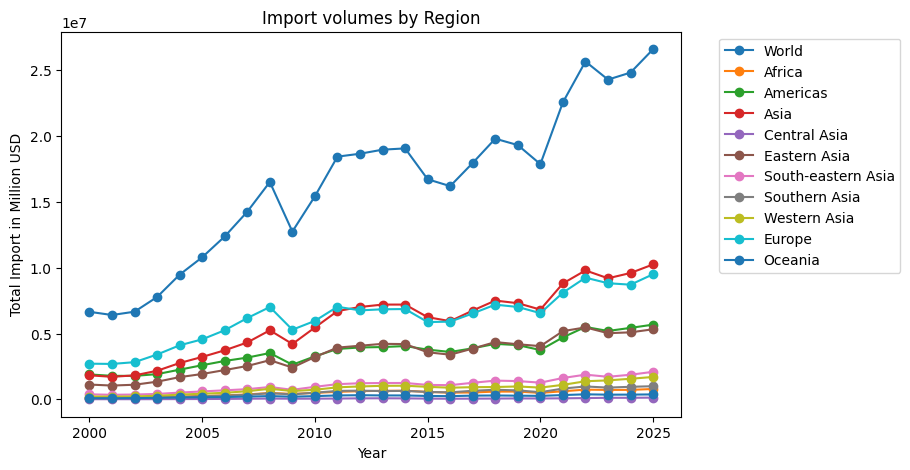

In [11]:
ax = import_data.T.plot.line(legend=False, marker='o',figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Total Import in Million USD')
ax.set_title('Import volumes by Region')
plt.show()

In [12]:
import_japan = pd.read_csv('TradeMerchTotal_Import.csv',
                          usecols=[0,*range(53,79)],
                          index_col=0,
                          names=['Region',*map(str,range(2000,2026))],
                          skiprows=lambda x: x == 0 or x != 18)

In [13]:
import_japan

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
Japan,379510,349089,337194,382930,454542,515866,579064,622243,762534,551981,...,607728,672096,748488,720957,635460,768976,899941,787199,743498,755553


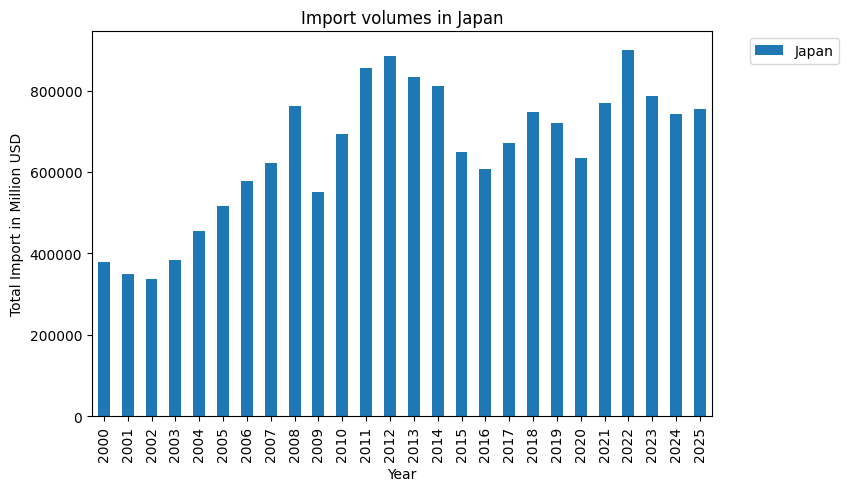

In [14]:
ax = import_japan.T.plot.bar(legend=False,figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Total Import in Million USD')
ax.set_title('Import volumes in Japan')
plt.show()

In [15]:
export_data = pd.read_csv('TradeMerchTotal_Export.csv',
                          usecols=[0,*range(53,79)],
                          index_col=0,
                          names=['Region',*map(str,range(2000,2026))],
                          skiprows=1,
                          nrows=11)

In [16]:
export_data

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
World,6449894,6192835,6497515,7585928,9218263,10512045,12135957,14030960,16170179,12577859,...,16049542,17737663,19547191,19008048,17647831,22289989,24915251,23902666,24501296,26257321
Africa,145190,136409,142499,175179,233964,301599,359385,425011,548224,387233,...,379944,436797,513150,481383,396301,560444,662286,619010,628002,689185
Americas,1426842,1342453,1302878,1388741,1613239,1848376,2114055,2355442,2651280,2076540,...,2726013,2957386,3193943,3142424,2767578,3474512,4083157,3986347,4092014,4290704
Asia,2068214,1883011,2032179,2421829,3040691,3591672,4238951,4928875,5798263,4612565,...,6559755,7288946,8050051,7811013,7449691,9542258,10578240,9955703,10489498,11359339
Central Asia,15431,15173,16257,21126,29877,39123,53313,67505,96679,61614,...,55095,68803,84493,86021,69401,89053,117816,119760,124233,123350
Eastern Asia,1258590,1140646,1245689,1487131,1865780,2136743,2493419,2908451,3266580,2683819,...,4044245,4411860,4742835,4622248,4648754,5844990,6076922,5751904,6104141,6632171
South-eastern Asia,430203,387046,407366,474761,569044,656582,769799,865121,989751,813796,...,1144036,1316372,1446018,1423333,1386144,1724718,1959974,1818171,1941987,2191660
Southern Asia,93119,90205,99161,117849,147227,189230,236331,279147,354973,285581,...,405098,463142,505373,467531,391528,555636,649714,616637,651242,655278
Western Asia,270872,249942,263706,320961,428762,569995,686089,808650,1090281,767755,...,911281,1028769,1271331,1211881,953864,1327861,1773815,1649232,1667895,1756880


In [17]:
export_data.shape

(11, 26)

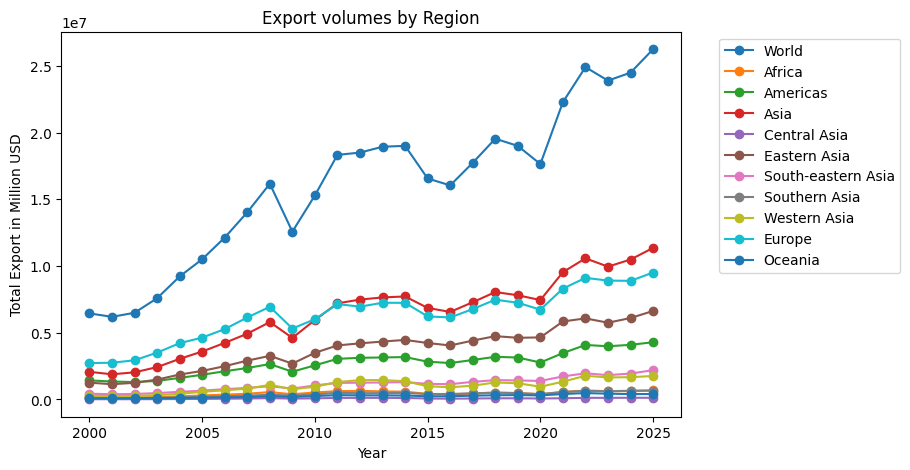

In [18]:
ax = export_data.T.plot.line(legend=False, marker='o',figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Total Export in Million USD')
ax.set_title('Export volumes by Region')
plt.show()

In [19]:
export_japan = pd.read_csv('TradeMerchTotal_Export.csv',
                          usecols=[0,*range(53,79)],
                          index_col=0,
                          names=['Region',*map(str,range(2000,2026))],
                          skiprows=lambda x: x == 0 or x != 18)

In [20]:
export_japan

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Region,,,,,,,,,,,,,,,,,,,,,
Japan,479296,403496,416726,471817,565675,594941,646725,714327,781412,580719,...,645052,698329,738143,705564,641319,756032,746824,717256,707009,738337


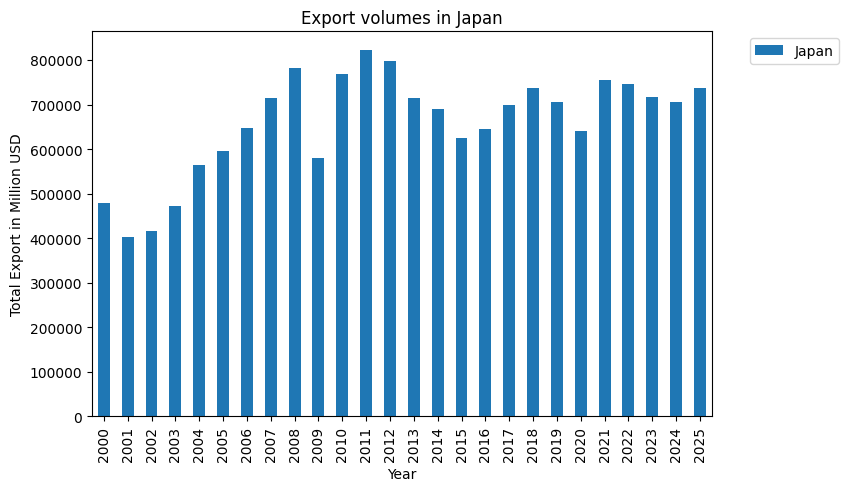

In [21]:
ax = export_japan.T.plot.bar(legend=False,figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Total Export in Million USD')
ax.set_title('Export volumes in Japan')
plt.show()

In [22]:
trade_japan = pd.concat([import_japan, export_japan], ignore_index=True).T
trade_japan.columns = ['Import', 'Export']

In [23]:
trade_japan

,Import,Export
2000,379510,479296
2001,349089,403496
2002,337194,416726
2003,382930,471817
2004,454542,565675
2005,515866,594941
2006,579064,646725
2007,622243,714327
2008,762534,781412
2009,551981,580719


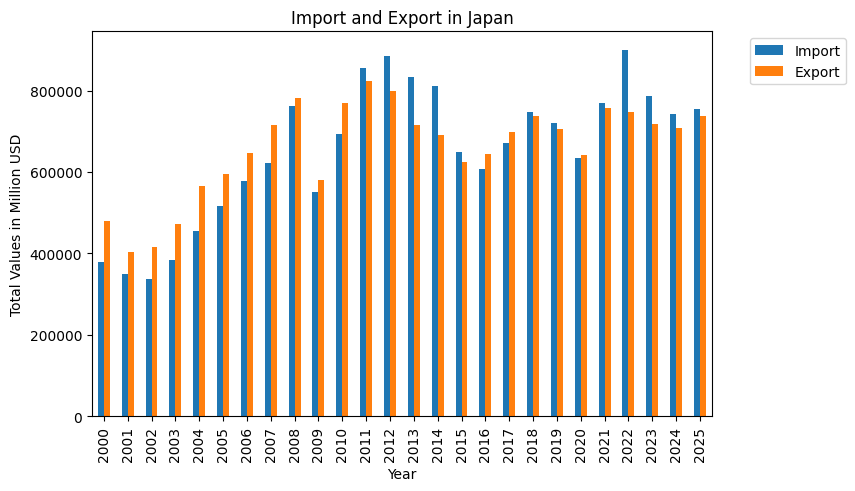

In [24]:
ax = trade_japan.plot.bar(legend=False,figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Total Values in Million USD')
ax.set_title('Import and Export in Japan')
plt.show()

### Fleets numbers

In [25]:
fleet_number = pd.read_csv('MerchantFleet_number.csv',
                           usecols=[0,*range(32,48)],
                           index_col=0,
                           names=['Region', *map(str, range(2011,2027))],
                           skiprows=1,
                           nrows=6)

In [26]:
fleet_number

,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Region,,,,,,,,,,,,,,,,
World,83282,84709,86667,87949,90470,92095,93518,95650,97133,100148,102172,104827,107744,110094,112782,115649
Africa,5525,5639,5987,6056,6250,6406,6646,6881,7183,7607,8043,8532,9325,9938,10601,11358
Americas,21020,20846,20808,20546,20459,20562,20499,20388,20314,20458,20439,20453,20666,20773,21516,21605
Asia,35108,35918,37498,38559,39845,40564,41851,43753,44802,46761,48028,49933,51550,53389,54312,55706
Europe,17104,17611,17325,17240,17342,17543,17548,17608,17619,17754,17849,17713,17372,16918,17231,17534
Oceania,3368,3554,3880,4167,4650,5050,5455,5738,5783,5976,6112,6432,6770,6996,6961,7122


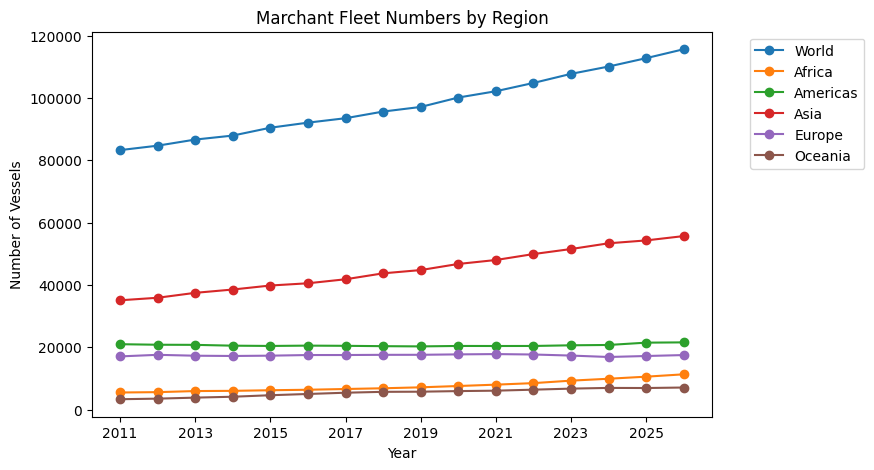

In [27]:
ax = fleet_number.T.plot.line(legend=False, marker='o',figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Vessels')
ax.set_title('Marchant Fleet Numbers by Region')
plt.show()

### Transportation capabilities

In [28]:
fleet_ton = pd.read_csv('MerchantFleet_ton.csv',
                           index_col=0,
                           names=['Region', *map(str, range(1980,2027))],
                           skiprows=1,
                           nrows=6)

In [29]:
fleet_ton

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Region,,,,,,,,,,,,,,,,,,,,,
World,672192,679755,686055,690098,681565,668145,654332,632238,625046,620734,...,1868251,1937777,1989924,2073311,2138844,2206295,2283273,2363141,2443569,2528788
Africa,167909,165985,155707,147478,141796,129956,122081,109764,105865,102174,...,234604,241566,261205,294396,325659,366408,412755,447619,473716,526090
Americas,78121,84072,90486,101618,108096,115840,119464,130503,138214,142196,...,488768,478861,475996,469606,482979,487562,504911,520956,537244,515803
Asia,131468,135572,144238,154365,164924,171993,180488,188813,198592,194544,...,569944,607511,633431,676435,685346,694133,707560,730674,749894,772183
Europe,291763,291277,292544,283366,263246,246421,228425,198663,177083,176135,...,341993,356816,359131,355850,352920,348033,336968,328108,346189,358712
Oceania,2931,2848,3080,3272,3503,3936,3874,4494,5292,5686,...,228081,250361,257430,273573,287508,304164,314155,327965,324024,334378


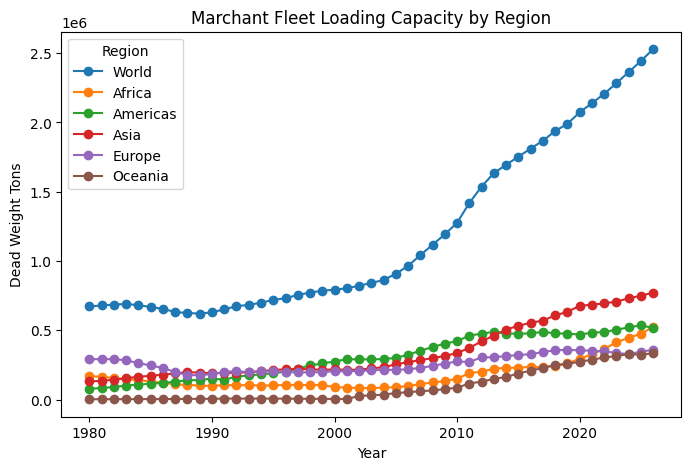

In [30]:
ax = fleet_ton.T.plot.line(legend=True, marker='o',figsize=(8, 5))
ax.set_xlabel('Year')
ax.set_ylabel('Dead Weight Tons')
ax.set_title('Marchant Fleet Loading Capacity by Region')
plt.show()

### Beneficial owners of ships

In [31]:
owner_data_20 = pd.read_csv('FleetBeneficialOwners_2020.csv',
                               usecols=[*range(0,28)],
                               index_col=0,
                               nrows=1).T

In [32]:
owner_data_20.index = owner_data_20.index.str.split('_').str[0]
owner_data_20 = owner_data_20.rename(columns={'World':'2020'})

In [33]:
owner_data_26 = pd.read_csv('FleetBeneficialOwners_2026.csv',
                               usecols=[*range(0,28)],
                               index_col=0,
                               nrows=1).T

In [34]:
owner_data_26.index = owner_data_26.index.str.split('_').str[0]
owner_data_26 = owner_data_26.rename(columns={'World':'2026'})

In [35]:
owner_data = pd.merge(owner_data_20, owner_data_26, left_index=True, right_index=True, how='inner')
owner_data = owner_data.dropna()

In [36]:
owner_data

BeneficialOwnership_Label,2020,2026
Bahamas,1319.0,1224.0
China,4931.0,7588.0
"China, Hong Kong SAR",2427.0,1937.0
Cyprus,972.0,925.0
Denmark,493.0,486.0
Greece,744.0,605.0
Indonesia,2353.0,2884.0
Iran (Islamic Republic of),270.0,326.0
Japan,938.0,1012.0
Liberia,3680.0,5756.0


In [37]:
owner_data_sorted = owner_data.sort_values(by='2026',ascending=True)
owner_data_sorted

BeneficialOwnership_Label,2020,2026
Saudi Arabia,153.0,224.0
Iran (Islamic Republic of),270.0,326.0
Denmark,493.0,486.0
Greece,744.0,605.0
United Kingdom,801.0,610.0
Republic of Korea,806.0,875.0
Cyprus,972.0,925.0
Japan,938.0,1012.0
Norway,1029.0,1049.0
Portugal,534.0,1124.0


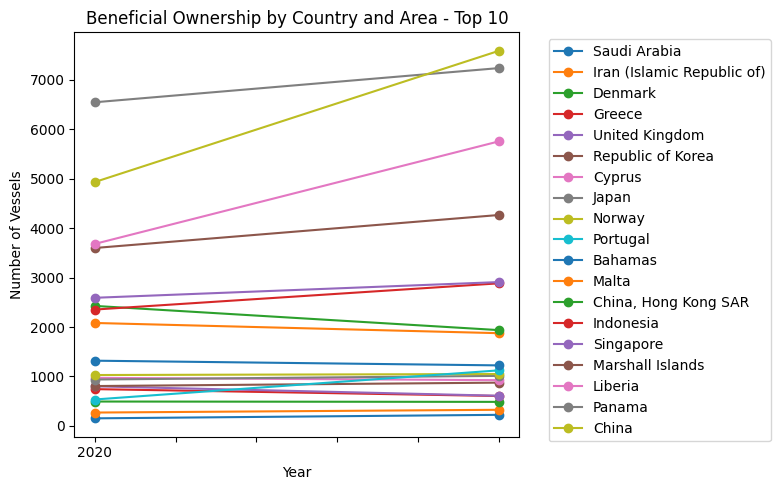

In [38]:
ax = owner_data_sorted.T.plot.line(legend=False, marker='o',figsize=(8, 5))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Year')
ax.set_ylabel('Number of Vessels')
ax.set_title('Beneficial Ownership by Country and Area - Top 10')

plt.tight_layout()
plt.show()

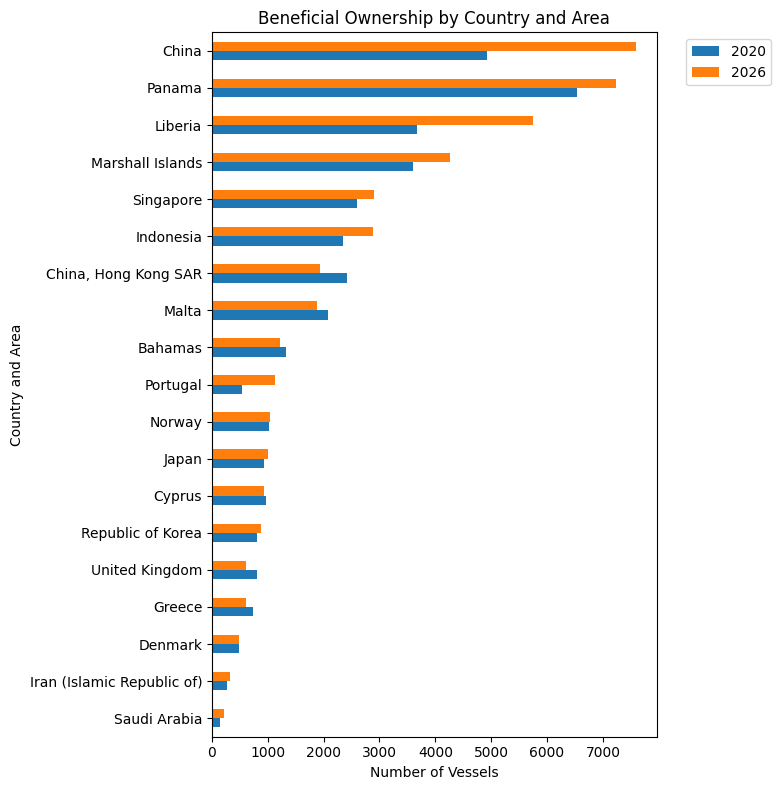

In [39]:
ax = owner_data_sorted.plot.barh(figsize=(8, 8))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Number of Vessels')
ax.set_ylabel('Country and Area')
ax.set_title('Beneficial Ownership by Country and Area')

plt.tight_layout()
plt.show()

### Port usability

In [40]:
accessive_port = pd.read_csv('PLSCI_index.csv',
                                 usecols=[0,82],
                                 names=['Port','PLSCI_2026Q2'],
                                 skiprows=1)

In [41]:
accessive_port[['Country', 'PortName']] = accessive_port['Port'].str.split(', ',n=1,expand=True)

In [42]:
accessive_port = accessive_port.drop(columns=['Port'])
accessive_port = accessive_port.dropna()
accessive_port = accessive_port[['Country', 'PortName', 'PLSCI_2026Q2']]

In [43]:
accessive_port

,Country,PortName,PLSCI_2026Q2
0,Albania,Durres,33.04
1,Algeria,Algiers,132.24
2,Algeria,Annaba,55.72
4,Algeria,Bejaia,44.64
5,Algeria,Djen Djen,11.48
...,...,...,...
1346,Viet Nam,Vung Tau,606.12
1347,Wallis and Futuna Islands,Futuna,8.47
1348,Wallis and Futuna Islands,Mata-Utu,8.47
1349,Yemen,Aden,70.87


In [44]:
accessive_port_sorted = accessive_port.sort_values(by='PLSCI_2026Q2',ascending=False)
top50_port =accessive_port_sorted.head(50)
top20_port =accessive_port_sorted.head(20)

In [45]:
top20_port.index = range(1, len(top20_port) +1)
top20_port

,Country,PortName,PLSCI_2026Q2
1,China,Shanghai,2372.47
2,China,Ningbo,2040.69
3,Singapore,Singapore,1833.94
4,Republic of Korea,Pusan,1655.17
5,China,Qingdao,1389.05
6,China,Shekou,1157.85
7,Malaysia,Port Klang,1075.80
8,China,Nansha,1071.13
9,China,"Hong Kong SAR, Hong Kong",976.84
10,Netherlands (Kingdom of the),Rotterdam,950.83


In [46]:
top50_port

,Country,PortName,PLSCI_2026Q2
211,China,Shanghai,2372.47
204,China,Ningbo,2040.69
1031,Singapore,Singapore,1833.94
969,Republic of Korea,Pusan,1655.17
206,China,Qingdao,1389.05
213,China,Shekou,1157.85
705,Malaysia,Port Klang,1075.80
202,China,Nansha,1071.13
187,China,"Hong Kong SAR, Hong Kong",976.84
771,Netherlands (Kingdom of the),Rotterdam,950.83


In [39]:
geolocator = Nominatim(user_agent="geo_application")

In [116]:
def get_lat_lon(row):
    # Find latitude and longitude by PortName and Country
    query = f"{row['PortName']}, {row['Country']}"
    try:
        location = geolocator.geocode(query)
        if location:
            return location.latitude, location.longitude
        else:
            # If it was not found, looking for PortName again
            location = geocode(row["PortName"])
            if location:
                return location.latitude, location.longitude
            return None, None
    except Exception as e:
        print(f"Error for {query}: {e}")
        return None, None

In [117]:
# An evidence of an error appeared when using geocode
# coordinates = top50_port.apply(get_lat_lon, axis=1)

Error for Rotterdam, Netherlands (Kingdom of the): name 'geocode' is not defined
Error for Taiwan Province of, Kaohsiung, China: name 'geocode' is not defined
Error for Haiphong, Viet Nam: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=Haiphong%2C+Viet+Nam&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))


KeyboardInterrupt: 

In [47]:
#  Generate dictionary of the location by Genetative AI
port_gps_master = {
    "Shanghai": (31.2304, 121.4737),
    "Ningbo": (29.8683, 121.5440),
    "Singapore": (1.3521, 103.8198),
    "Pusan": (35.1796, 129.0756),
    "Qingdao": (36.0671, 120.3826),
    "Shekou": (22.4828, 113.9154),
    "Port Klang": (3.0003, 101.4011),
    "Nansha": (22.7744, 113.6094),
    "Hong Kong SAR, Hong Kong": (22.3193, 114.1694),
    "Rotterdam": (51.9244, 4.4777),
    "Antwerp": (51.2194, 4.4025),
    "Xiamen": (24.4798, 118.0894),
    "Taiwan Province of, Kaohsiung": (22.6273, 120.3014),
    "Yantian": (22.5752, 114.2778),
    "Xingang": (38.9841, 117.7725),
    "Laem Chabang": (13.0911, 100.8924),
    "Colombo": (6.9271, 79.8612),
    "Yokohama": (35.4437, 139.6380),
    "Haiphong": (20.8449, 106.6881),
    "Hamburg": (53.5511, 9.9937),
    "Mundra": (22.8364, 69.7289),
    "Nhava Sheva": (18.9497, 72.9511),
    "Ho Chi Minh City": (10.8231, 106.6297),
    "Vung Tau": (10.3460, 107.0843),
    "Dalian": (38.9140, 121.6147),
    "Tanger Med": (35.8883, -5.5008),
    "Valencia": (39.4699, -0.3763),
    "Tanjung Pelepas": (1.3622, 103.5451),
    "Tokyo": (35.6762, 139.6503),
    "Nagoya": (35.1815, 136.9066),
    "Jakarta": (-6.2088, 106.8456),
    "Kobe": (34.6901, 135.1955),
    "Bremerhaven": (53.5396, 8.5805),
    "Kwangyang (Gwangyang)": (34.9402, 127.6958),
    "Algeciras": (36.1408, -5.4562),
    "Ambarli": (40.9708, 28.6917),
    "New York/New Jersey": (40.7128, -74.0060),
    "Manila": (14.5995, 120.9842),
    "Barcelona": (41.3851, 2.1734),
    "Jeddah": (21.3256, 39.1171),
    "Savannah": (32.0809, -81.0912),
    "Incheon": (37.4563, 126.7052),
    "Le Havre": (49.4944, 0.1079),
    "Piraeus": (37.9356, 23.6484),
    "Genoa": (44.4056, 8.9463),
    "Cartagena (CO)": (10.3910, -75.4794),
    "Surabaya": (-7.2575, 112.7521),
    "Osaka": (34.6937, 135.5022),
    "Norfolk": (36.8508, -76.2859),
    "London Gateway": (51.5140, 0.4628),
}

In [48]:
top50_port["latitude"] = top50_port['PortName'].map(port_gps_master).str[0]
top50_port["longitude"] = top50_port['PortName'].map(port_gps_master).str[1]

/tmp/ipykernel_3288577/3112588139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top50_port["latitude"] = top50_port['PortName'].map(port_gps_master).str[0]
/tmp/ipykernel_3288577/3112588139.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top50_port["longitude"] = top50_port['PortName'].map(port_gps_master).str[1]


In [49]:
top50_port

,Country,PortName,PLSCI_2026Q2,latitude,longitude
211,China,Shanghai,2372.47,31.2304,121.4737
204,China,Ningbo,2040.69,29.8683,121.5440
1031,Singapore,Singapore,1833.94,1.3521,103.8198
969,Republic of Korea,Pusan,1655.17,35.1796,129.0756
206,China,Qingdao,1389.05,36.0671,120.3826
213,China,Shekou,1157.85,22.4828,113.9154
705,Malaysia,Port Klang,1075.80,3.0003,101.4011
202,China,Nansha,1071.13,22.7744,113.6094
187,China,"Hong Kong SAR, Hong Kong",976.84,22.3193,114.1694
771,Netherlands (Kingdom of the),Rotterdam,950.83,51.9244,4.4777


In [50]:
layer = pdk.Layer(
    "ColumnLayer",
    data=top50_port,
    get_position="[longitude, latitude]",
    get_elevation="PLSCI_2026Q2",
    elevation_scale=1000,
    radius=100000,
    get_fill_color="[255, 165, 0, 200]",
    pickable=True,
    auto_highlight=True,
)

In [51]:
view_state = pdk.ViewState(
    latitude=30.5,
    longitude=121.5,
    zoom=1,
    pitch=45,
)

In [52]:
pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    map_style='road').to_html("top50_port.html")

### Japanese shipping companies' stock price

#### Closing prices

In [53]:
# Major three Japanese shipping companies
# Nippon Yusen 9101.T, Mitsui OSK 9104.T, Kawasaki Kisen 9107.T
tickers = ["9101.T", "9104.T", "9107.T"]

In [54]:
stock_data = yf.download(tickers, period="5y")

[*********************100%***********************]  2 of 3 completed

1 Failed download:
['9107.T']: TypeError("'NoneType' object is not subscriptable")
[*********************100%***********************]  2 of 3 completed

In [55]:
st_close = stock_data['Close'].copy()

In [56]:
st_close.columns = ['Nippon Yusen', 'Mitsui OSK', 'Kawasaki Kisen' ]

In [57]:
st_close

,Nippon Yusen,Mitsui OSK,Kawasaki Kisen
Date,,,
2021-09-13,2073.903564,1998.840454,NaN
2021-09-14,2101.330566,2045.898193,NaN
2021-09-15,2183.611572,2106.400879,NaN
2021-09-16,2122.427979,2063.824463,NaN
2021-09-17,2183.611572,2128.809570,NaN
...,...,...,...
2026-09-07,7420.000000,7164.000000,NaN
2026-09-08,7290.000000,7114.000000,NaN
2026-09-09,7201.000000,7039.000000,NaN


In [59]:
close_df = stock_data['Close']

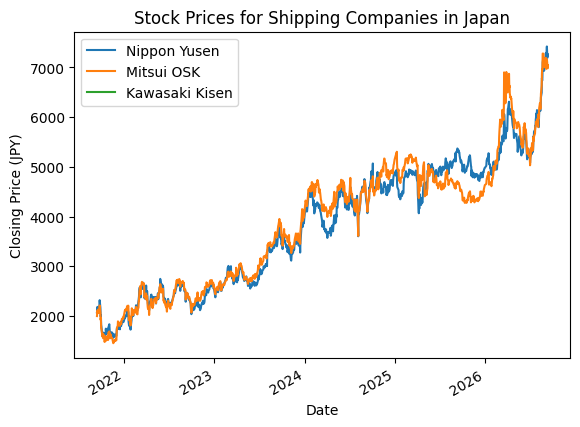

In [60]:
st_close.plot()
plt.title('Stock Prices for Shipping Companies in Japan')
plt.ylabel('Closing Price (JPY)')
plt.show()

#### Stock price differences

In [61]:
yusen = yf.Ticker('9101.T').history(start='2019-01-01', interval='1d')['Close']
shosen = yf.Ticker('9104.T').history(start='2019-01-01', interval='1d')['Close']
kisen = yf.Ticker('9107.T').history(start='2019-01-01', interval='1d')['Close']

In [62]:
yusen_diffs = (yusen - yusen.shift())[1:]
shosen_diffs = (shosen - shosen.shift())[1:]
kisen_diffs = (kisen - kisen.shift())[1:]

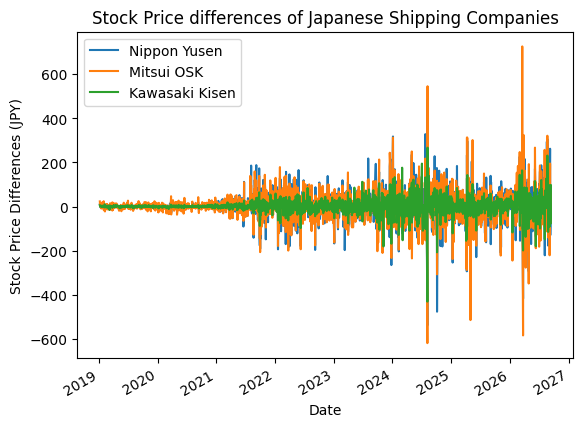

In [63]:
yusen_diffs.plot(label='Nippon Yusen')
shosen_diffs.plot(label='Mitsui OSK')
kisen_diffs.plot(label='Kawasaki Kisen')

plt.title('Stock Price differences of Japanese Shipping Companies')
plt.ylabel('Stock Price Differences (JPY)')
plt.legend()
plt.show()

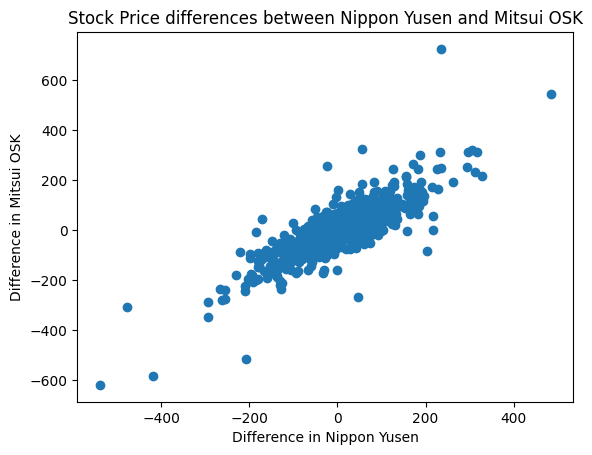

In [64]:
plt.scatter(yusen_diffs, shosen_diffs)
plt.xlabel('Difference in Nippon Yusen')
plt.ylabel('Difference in Mitsui OSK')

plt.title('Stock Price differences between Nippon Yusen and Mitsui OSK')
plt.show()

Text(0.5, 1.0, 'Stock Price differences between Nippon Yusen and Kawasaki Kisen')

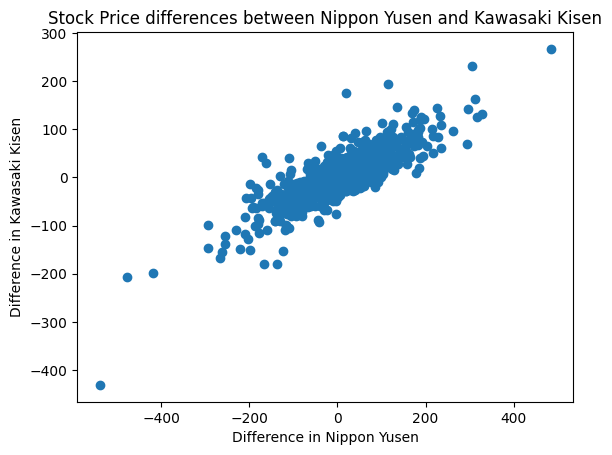

In [65]:
plt.scatter(yusen_diffs, kisen_diffs)
plt.xlabel('Difference in Nippon Yusen')
plt.ylabel('Difference in Kawasaki Kisen')

plt.title('Stock Price differences between Nippon Yusen and Kawasaki Kisen')

Text(0.5, 1.0, 'Stock Price differences between Mitsui OSK and Kawasaki Kisen')

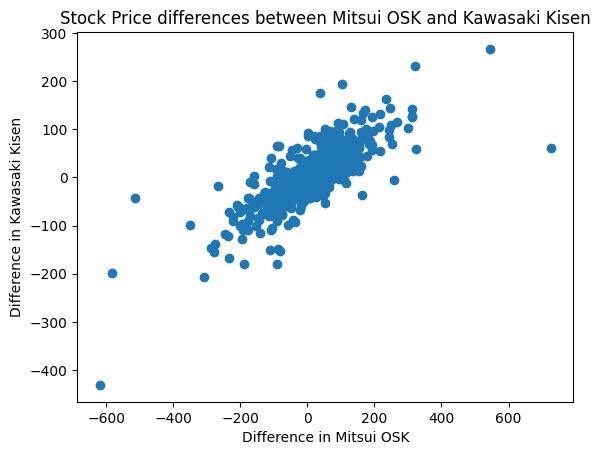

In [66]:
plt.scatter(shosen_diffs, kisen_diffs)

plt.xlabel('Difference in Mitsui OSK')
plt.ylabel('Difference in Kawasaki Kisen')

plt.title('Stock Price differences between Mitsui OSK and Kawasaki Kisen')

#### Stock price beta

In [67]:
def covariance(x,y):
    return (x * y).mean() - x.mean() * y.mean()

In [68]:
def beta(x,y):
    return covariance(x,y) / covariance(x,x)

In [69]:
beta_1_yusen_mitsui = beta(yusen_diffs, shosen_diffs)
beta_2_mitsui_yusen = beta(shosen_diffs, yusen_diffs)
beta_3_yusen_kawasaki = beta(yusen_diffs, kisen_diffs)
beta_4_kawasaki_yusen = beta(kisen_diffs, yusen_diffs)
beta_5_mitsui_kawasaki = beta(shosen_diffs, kisen_diffs)
beta_6_kawasaki_mitsui = beta(kisen_diffs, shosen_diffs)

In [70]:
beta_data = {
    "Yusen vs Mitsui": float(beta_1_yusen_mitsui),
    "Mitsui vs Yusen": float(beta_2_mitsui_yusen),
    "Yusen vs Kisen": float(beta_3_yusen_kawasaki),
    "Kisen vs Yusen": float(beta_4_kawasaki_yusen),
    "Mitsui vs Kisen": float(beta_5_mitsui_kawasaki),
    "Kisen vs Mitsui": float(beta_6_kawasaki_mitsui),
}

In [71]:
df_beta = pd.Series(beta_data)

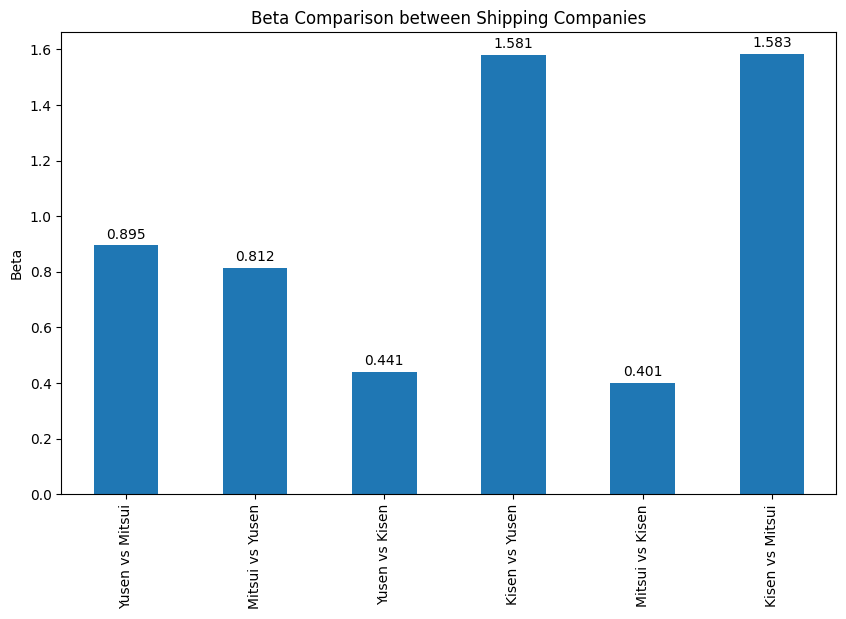

In [72]:
ax = df_beta.plot.bar(figsize=(10, 6))
ax.bar_label(ax.containers[0], padding=3, fmt="%.3f")

# 2. 受け取った ax に対してラベルやタイトルを設定する
ax.set_ylabel('Beta')
ax.set_title('Beta Comparison between Shipping Companies')

# 3. グラフをきれいに表示（Jupyter等での2重表示を防ぐ）
plt.show()

#### Stock price prediction interval

In [73]:
df = yf.download(tickers, start="2022-01-01")["Close"].tz_localize(None)

[*********************100%***********************]  3 of 3 completed


In [74]:
df.columns = ['Nippon Yusen', 'Mitsui OSK', 'Kawasaki Kisen' ]

In [75]:
future_dates = pd.date_range(df.index[-1], periods=61, freq="B")[1:]

/home/kkura001/.local/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kkura001/.local/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kkura001/.local/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/kkura001/.local/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  retur

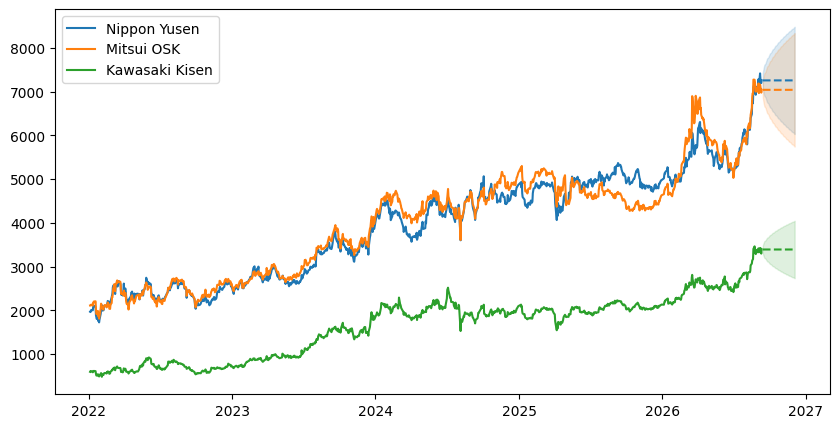

In [76]:
plt.figure(figsize=(10, 5))

for col in df.columns:
    # Plot acctual values
    (line,) = plt.plot(df.index, df[col], label=col)

    # Prediction by ARIMA
    res = ARIMA(df[col], order=(1, 1, 0)).fit()
    fc = res.get_forecast(steps=60)

    # Plot future prediction in future date
    plt.plot(future_dates, fc.predicted_mean, linestyle="--", color=line.get_color())
    plt.fill_between(
        future_dates,
        fc.conf_int().iloc[:, 0],
        fc.conf_int().iloc[:, 1],
        color=line.get_color(),
        alpha=0.15,
    )

plt.legend()
plt.show()